# Tests of the sliding diffusion concept

The following with be experiements and tests of hyperparameter configurations, sometimes with numerical evalusaions, and prints for analasis. 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from local_attention import transformer
from local_attention.rotary import SinusoidalEmbeddings, apply_rotary_pos_emb
import matplotlib.pyplot as plt
from typing import Union
from io import BytesIO
from PIL import Image
from moviepy import ImageSequenceClip
from datetime import datetime
from v1_sliding_diffusion import Diffusion

import wandb

In [2]:
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: pefu (pefu-it-university-of-copenhagen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu")

sqrt_alpha_hats torch.Size([100]) tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9999, 0.9931, 0.9797, 0.9598,
        0.9338, 0.9020, 0.8651, 0.8237, 0.7785, 0.7302, 0.6797, 0.6279, 0.5754,
        0.5231, 0.4718, 0.4219, 0.3742, 0.3290, 0.2868, 0.2478, 0.2122, 0.1801,
        0.1514, 0.1260, 0.1039, 0.0849, 0.0686, 0.0549, 0.0434, 0.0340, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000])
sqrt_one_minus_alpha_hats torch.Size([100]) tensor([0.0000, 0.0000, 0

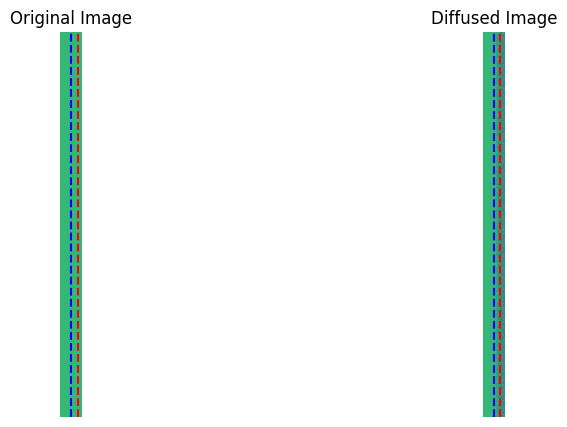

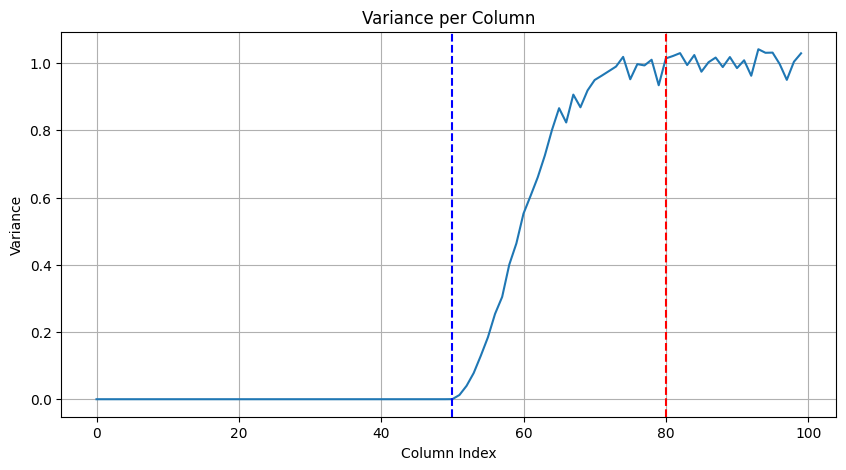

In [4]:
# Initialize the diffusion class
diffusion = Diffusion(
        num_of_pre_timestep_frames = 50, 
        num_of_timestep_frames = 30, 
        num_of_post_timestep_frames = 20, 
        noise_schedule = Diffusion.linear_schedule(0.0002, 0.40), 
        device = device 
    )

# Create a tensor that is all white so we can see the noising process removing details
image = torch.ones((177 * 10, 100))
image = image.to(device)

# Run the forward diffusion function
transformed_image = diffusion.forward(seqence_tensor = image)

# Draw both images next to each other in the python notebook
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image.cpu().numpy(), vmin=-3, vmax=3)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(transformed_image.cpu().numpy(), vmin=-3, vmax=3)
ax[1].set_title("Diffused Image")
ax[1].axis("off")

# Draw a vertical line at num_of_pre_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames
for a in ax:
    a.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
    a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

# Draw a vertical line at num_of_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames + diffusion.num_of_timestep_frames
for a in ax:
    a.axvline(x=line_x, color='red', linestyle='--', label='Timestep frames')
    a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

plt.show()

# Calculate the variance per frame (vertical slice)
variances = torch.var(transformed_image, dim=0)

# Plot the variance for each column
plt.figure(figsize=(10, 5))
plt.plot(variances.cpu().numpy())
plt.title("Variance per Column")
plt.xlabel("Column Index")
plt.ylabel("Variance")
plt.grid(True)

# Draw vertical lines at num_of_pre_timestep_frames and num_of_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames
plt.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
plt.axvline(x=line_x + diffusion.num_of_timestep_frames, color='red', linestyle='--', label='Timestep frames')


plt.show()

In [5]:
from v1_model import ContinuousMotionModel
from debugger import Debugger
from v1_traing_loop import train
from v1_sliding_diffusion import Diffusion

### Experiment 01

In [6]:
model = ContinuousMotionModel(
        deffsion_noise_scheduler=Diffusion(
            device=device,
            num_of_pre_timestep_frames=50,
            num_of_timestep_frames=100,
            num_of_post_timestep_frames=0,
            noise_schedule=Diffusion.linear_schedule(0.0002, 0.005)),
        number_of_styles = 17,
        n_gesture_length = 150,
        audio_features_per_frame = 804,
        pose_features_per_frame = 345,
        number_of_attention_heads = 8,
        debugger = Debugger(
            on=True, 
            keys_for_printing_while_running=["ALL"]
        ),
        device=device,
)

sqrt_alpha_hats torch.Size([150]) tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9999, 0.9998, 0.9996, 0.9995,
        0.9993, 0.9990, 0.9988, 0.9985, 0.9982, 0.9979, 0.9976, 0.9972, 0.9968,
        0.9964, 0.9960, 0.9955, 0.9950, 0.9945, 0.9940, 0.9935, 0.9929, 0.9923,
        0.9917, 0.9910, 0.9903, 0.9896, 0.9889, 0.9882, 0.9874, 0.9866, 0.9858,
        0.9850, 0.9841, 0.9833, 0.9824, 0.9814, 0.9805, 0.9795, 0.9785, 0.9775,
        0.9765, 0.9754, 0.9743, 0.9732, 0.9721, 0.9710, 0.9698, 0.9686, 0.9674,
        0.9662, 0.9649, 0.9636, 0.9623, 0.9610, 0.9597, 0.9583, 0.9569, 0.9555,
      

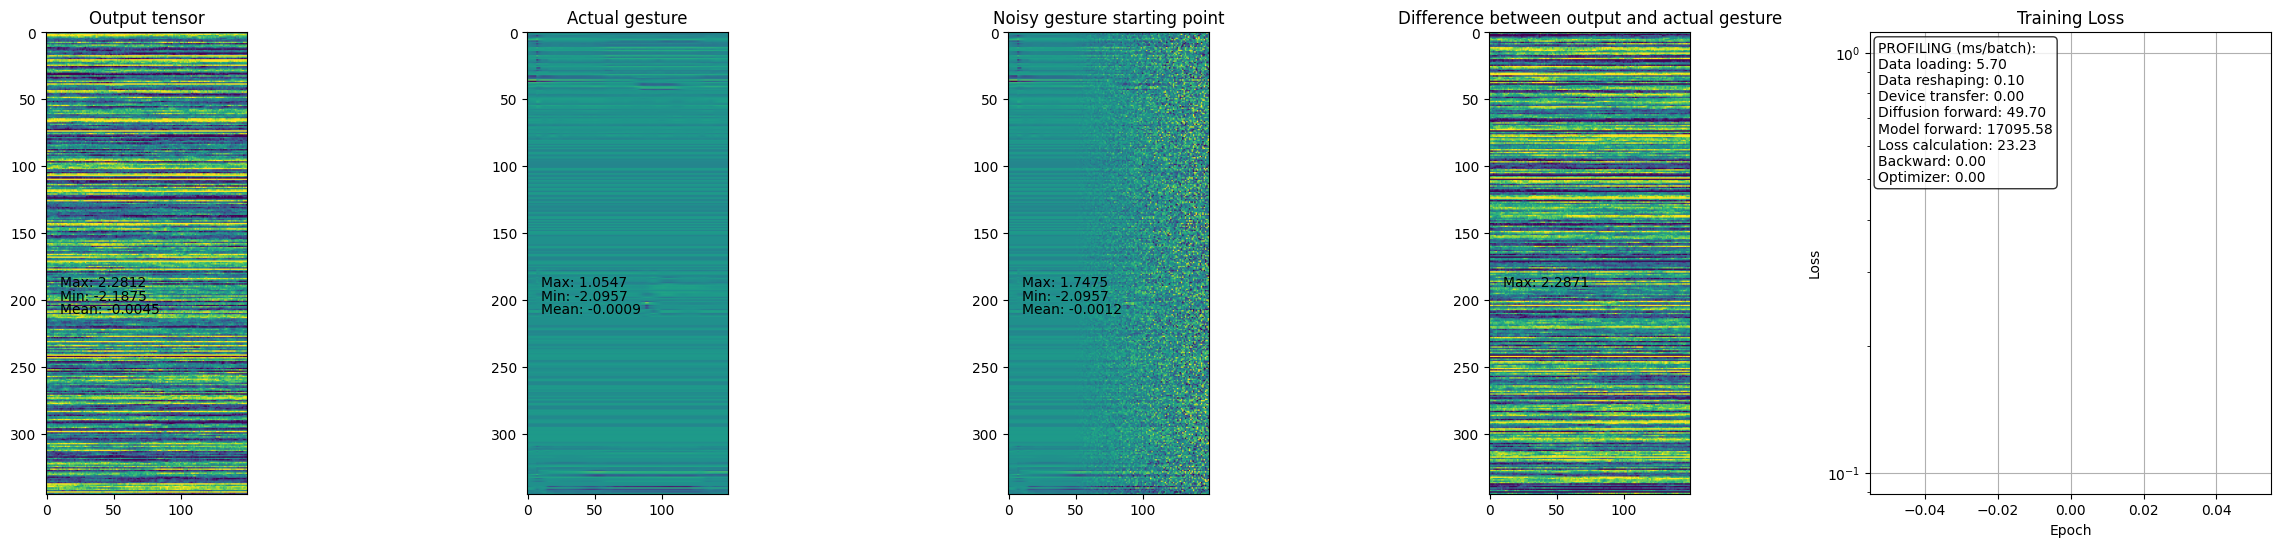

Visualisation time: 5.76 s
Checking for float16 tensors before backward...


C:\Users\peter\AppData\Roaming\Python\Python313\site-packages\torch\_functorch\_aot_autograd\utils.py:130: UserWarning: Your compiler for AOTAutograd is returning a function that doesn't take boxed arguments. Please wrap it with functorch.compile.make_boxed_func or handle the boxed arguments yourself. See https://github.com/pytorch/pytorch/pull/83137#issuecomment-1211320670 for rationale.
  warnings.warn(
Epoch 1/1: 100%|██████████| 1/1 [01:27<00:00, 87.57s/it, loss=0.191]
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


train/loss,▁
train/loss,0.19103


[0.19103220105171204]

In [ ]:
from torch.utils.data import DataLoader
from dataset.dataset import *

train(
    debug_run=True,
    experiment_collection_name="first_tests",
    model=model,
    device=device,
    training_loader=DataLoader(
            ConsolidatedRAMDataset(
                consolidated_file= "dataset/genea2023_dataset/trn/main-agent/consolidated.npz", # or "dataset/genea2023_dataset/trn/main-agent/training_windows_100k.npz"
                seq_length=150,
                seed_length=8,
                batch_size=10,
                epoch_length=1
            ),
            batch_size = 1,
            num_workers = 0,
            pin_memory = True
        ),
    val_loader=None, 
    num_epochs=1)

one_hot_style  max value:  tensor(1., dtype=torch.float16)
one_hot_style  min value:  tensor(0., dtype=torch.float16)
audio_features  max value:  tensor(24.4688, dtype=torch.float16)
audio_features  min value:  tensor(-15.3047, dtype=torch.float16)
noisy_gesture_sequence  max value:  tensor(1.7475)
noisy_gesture_sequence  min value:  tensor(-2.0957)
timestep_0_pos_embedding  max value:  tensor(0.0064, dtype=torch.bfloat16, grad_fn=<MaxBackward1>)
timestep_0_pos_embedding  min value:  tensor(-0.0050, dtype=torch.bfloat16, grad_fn=<MinBackward1>)


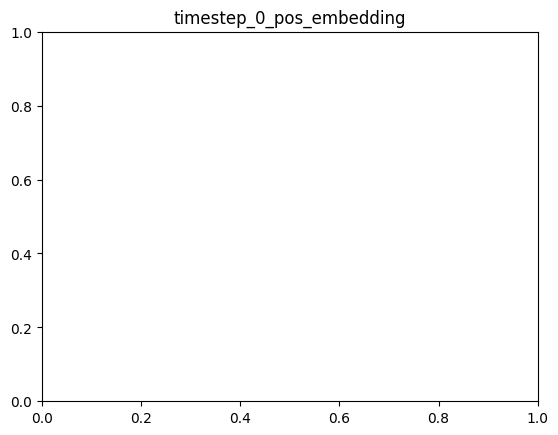

timestep_max_pos_embedding  max value:  tensor(0.4121, dtype=torch.bfloat16, grad_fn=<MaxBackward1>)
timestep_max_pos_embedding  min value:  tensor(-0.4922, dtype=torch.bfloat16, grad_fn=<MinBackward1>)


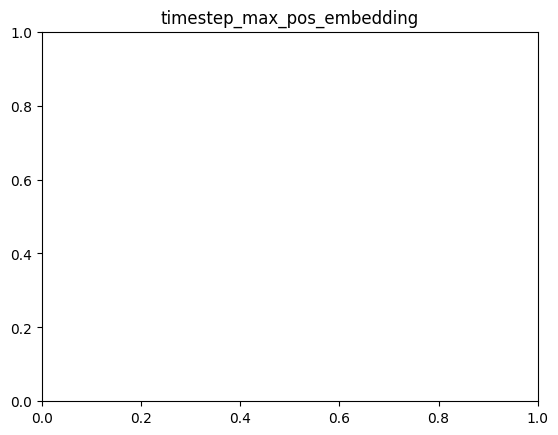

t_for_each_timestep_frame  max value:  tensor(0.9900)
t_for_each_timestep_frame  min value:  tensor(0.)


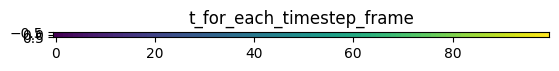

t_with_pos_embedding_for_each_timestep_frame - should be (t_for_each_timestep_frame, 192)  max value:  tensor(0.6875, dtype=torch.bfloat16, grad_fn=<MaxBackward1>)
t_with_pos_embedding_for_each_timestep_frame - should be (t_for_each_timestep_frame, 192)  min value:  tensor(-0.7109, dtype=torch.bfloat16, grad_fn=<MinBackward1>)


TypeError: Got unsupported ScalarType BFloat16

In [8]:
model.debugger.get_available_keys()
model.debugger.print_from_key("ALL")
